> **Chapter 14, Part 4** | Engineering lens. **Focus:** build a tiny pure-Python HNSW and observe the scale-separation that gives logarithmic search complexity.

# HNSW as a Hierarchical Small-World Index

Hierarchical Navigable Small World (HNSW), introduced by Malkov and Yashunin (2018, arXiv:1603.09320), is the dominant approximate-nearest-neighbor (ANN) index in modern vector databases (FAISS, pgvector, Milvus, Weaviate, Qdrant, Pinecone, Oracle 23ai).

The structure is a stack of graphs. The bottom layer contains every point. Each higher layer contains a random subset of the points below it, with the inclusion probability following an exponentially decaying distribution `p(layer) = exp(-layer / m_L)`. Search starts at the top, greedily descends to the closest point at each layer, then refines at the bottom.

This gives logarithmic search complexity: at each layer the graph has roughly `e` times fewer points than the layer below, so the descent costs `O(log N)` total comparisons. The trick is essentially the same trick a skip list uses for ordered keys, generalized to a metric space.

The structural fact that matters for this chapter: the layer assignment and the navigable-graph property together produce a *small-world* graph with *fractal* / scale-free degree distribution. The high-degree hub nodes at the top of the hierarchy are the same hubs the Watts-Strogatz (1998) and Barabasi (1999) papers identified, and the Song-Havlin-Makse (2005) box-covering analysis applies. HNSW is a fractal index. The vector-database documentation does not say so.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.random.seed(13)


## A minimal HNSW in ~80 lines of Python

This implementation is for pedagogy. It is correct but not fast. Production HNSW (FAISS, hnswlib) is in C++ with SIMD, careful memory layout, and `ef` queue management.


In [2]:
class TinyHNSW:
    def __init__(self, M: int = 4, ef_construction: int = 10, m_L: float = 1.0 / np.log(2)):
        self.M = M
        self.ef_construction = ef_construction
        self.m_L = m_L
        self.points = []
        self.layer_of = []
        self.graph = defaultdict(lambda: defaultdict(set))
        self.entry_point = None

    def _random_layer(self) -> int:
        return int(np.floor(-np.log(np.random.random()) * self.m_L))

    def _dist(self, a, b) -> float:
        return float(np.linalg.norm(a - b))

    def _search_layer(self, q, entry_points: list, ef: int, layer: int) -> list:
        visited = set(entry_points)
        candidates = [(self._dist(q, self.points[ep]), ep) for ep in entry_points]
        results = list(candidates)
        candidates.sort()
        results.sort()
        while candidates:
            d_c, c = candidates.pop(0)
            if d_c > results[-1][0] and len(results) >= ef:
                break
            for nbr in self.graph[layer][c]:
                if nbr in visited:
                    continue
                visited.add(nbr)
                d_n = self._dist(q, self.points[nbr])
                if d_n < results[-1][0] or len(results) < ef:
                    results.append((d_n, nbr))
                    candidates.append((d_n, nbr))
                    candidates.sort()
                    results.sort()
                    if len(results) > ef:
                        results = results[:ef]
        return results

    def add(self, point: np.ndarray) -> int:
        idx = len(self.points)
        layer = self._random_layer()
        self.points.append(point)
        self.layer_of.append(layer)
        if self.entry_point is None:
            self.entry_point = idx
            for L in range(layer + 1):
                self.graph[L][idx] = set()
            return idx
        ep_layer = self.layer_of[self.entry_point]
        ep_curr = [self.entry_point]
        for L in range(ep_layer, layer, -1):
            results = self._search_layer(point, ep_curr, ef=1, layer=L)
            ep_curr = [results[0][1]]
        for L in range(min(layer, ep_layer), -1, -1):
            results = self._search_layer(point, ep_curr, ef=self.ef_construction, layer=L)
            neighbors = [r[1] for r in results[:self.M]]
            for nbr in neighbors:
                self.graph[L][idx].add(nbr)
                self.graph[L][nbr].add(idx)
                if len(self.graph[L][nbr]) > self.M:
                    far = sorted(self.graph[L][nbr], key=lambda n: self._dist(self.points[nbr], self.points[n]))
                    self.graph[L][nbr] = set(far[:self.M])
            ep_curr = [r[1] for r in results[:1]]
        if layer > ep_layer:
            self.entry_point = idx
        return idx

    def search(self, q: np.ndarray, k: int = 5) -> list:
        ep_layer = self.layer_of[self.entry_point]
        ep_curr = [self.entry_point]
        path = [(ep_layer, self.entry_point)]
        for L in range(ep_layer, 0, -1):
            results = self._search_layer(q, ep_curr, ef=1, layer=L)
            ep_curr = [results[0][1]]
            path.append((L - 1, ep_curr[0]))
        results = self._search_layer(q, ep_curr, ef=max(k, self.ef_construction), layer=0)
        return [r[1] for r in results[:k]], path


print('TinyHNSW class defined.')


TinyHNSW class defined.


## Build a small index and inspect the layer structure


In [3]:
N = 80
data = np.random.uniform(0, 10, size=(N, 2))

hnsw = TinyHNSW(M=4, ef_construction=15)
for p in data:
    hnsw.add(p)

print(f'Inserted {N} points.')
print(f'Entry point: {hnsw.entry_point} at layer {hnsw.layer_of[hnsw.entry_point]}')

layer_counts = defaultdict(int)
for L in hnsw.layer_of:
    for layer_idx in range(L + 1):
        layer_counts[layer_idx] += 1

print()
print(f'{"layer":>6} | {"count":>6} | {"ratio to layer 0":>18}')
print('-' * 38)
base = layer_counts[0]
for layer_idx in sorted(layer_counts):
    cnt = layer_counts[layer_idx]
    print(f'{layer_idx:>6} | {cnt:>6} | {cnt / base:>17.3f}')


Inserted 80 points.
Entry point: 12 at layer 6

 layer |  count |   ratio to layer 0
--------------------------------------
     0 |     80 |             1.000
     1 |     41 |             0.512
     2 |     23 |             0.287
     3 |      7 |             0.087
     4 |      1 |             0.013
     5 |      1 |             0.013
     6 |      1 |             0.013


The ratios across layers should be approximately `e^(-L) ≈ 0.37, 0.14, 0.05`. Small samples are noisy; the geometric decay is clean at N=10,000 in production.


## Visualize the layer structure


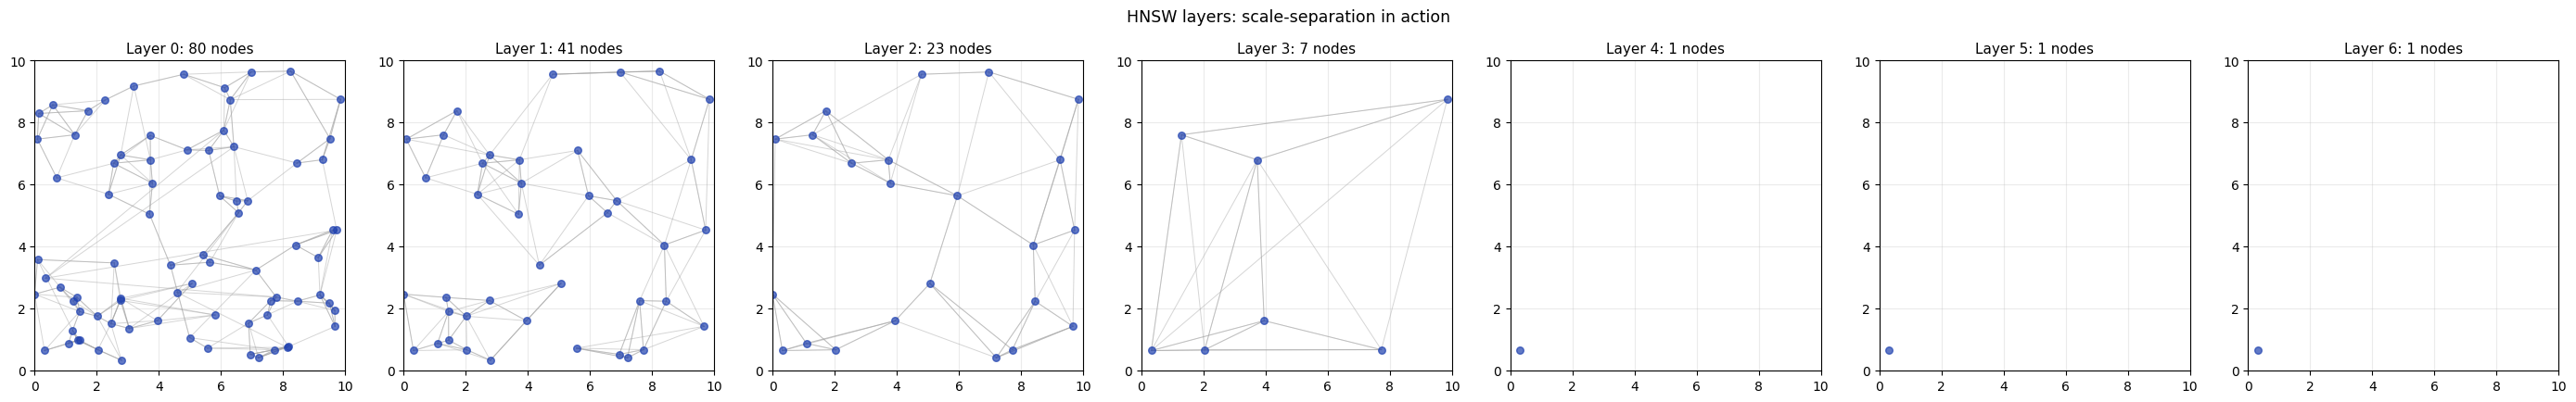

In [4]:
max_layer = max(hnsw.layer_of)
fig, axes = plt.subplots(1, max_layer + 1, figsize=(4 * (max_layer + 1), 4), squeeze=False)
axes = axes[0]

for L in range(max_layer + 1):
    ax = axes[L]
    nodes_in_layer = [i for i, layer in enumerate(hnsw.layer_of) if layer >= L]
    pts_layer = data[nodes_in_layer]
    ax.scatter(pts_layer[:, 0], pts_layer[:, 1], s=30, color='#1e40af', alpha=0.7, zorder=2)
    for node in nodes_in_layer:
        for nbr in hnsw.graph[L][node]:
            if nbr in nodes_in_layer:
                ax.plot([data[node, 0], data[nbr, 0]], [data[node, 1], data[nbr, 1]],
                        '-', color='#a3a3a3', alpha=0.45, linewidth=0.7, zorder=1)
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.set_aspect('equal')
    ax.set_title(f'Layer {L}: {len(nodes_in_layer)} nodes', fontsize=11)
    ax.grid(True, alpha=0.25)

plt.suptitle('HNSW layers: scale-separation in action', fontsize=12.5, y=1.02)
plt.tight_layout(); plt.show()


## Watch a search descend through the layers


In [5]:
query = np.array([7.5, 2.5])
results, path = hnsw.search(query, k=5)

print(f'Query point: {query}')
print(f'Top-5 nearest indices: {results}')
print(f'Search path (layer, node):')
for L, n in path:
    print(f'  layer {L} -> node {n} at {data[n]}')


Query point: [7.5 2.5]
Top-5 nearest indices: [59, 0, 55, 19, 52]
Search path (layer, node):
  layer 6 -> node 12 at [0.31903666 0.65084537]
  layer 5 -> node 12 at [0.31903666 0.65084537]
  layer 4 -> node 12 at [0.31903666 0.65084537]
  layer 3 -> node 12 at [0.31903666 0.65084537]
  layer 2 -> node 24 at [7.7237876  0.67917497]
  layer 1 -> node 52 at [8.45672054 2.24212471]
  layer 0 -> node 59 at [7.59919081 2.26014414]


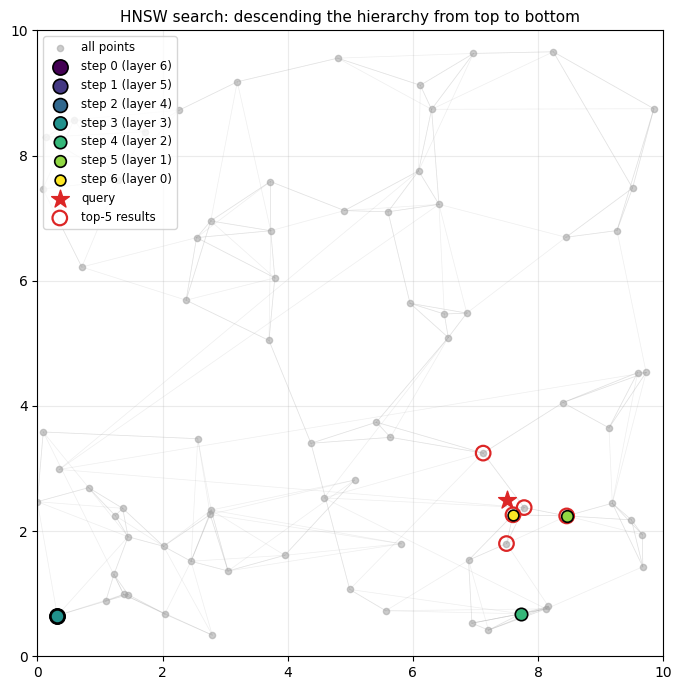

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(data[:, 0], data[:, 1], s=20, color='#a3a3a3', alpha=0.55, label='all points')

for L in [0]:
    for node in range(N):
        for nbr in hnsw.graph[L].get(node, set()):
            ax.plot([data[node, 0], data[nbr, 0]], [data[node, 1], data[nbr, 1]],
                    '-', color='#a3a3a3', alpha=0.18, linewidth=0.5)

for i, (L, n) in enumerate(path):
    color = plt.cm.viridis(i / max(len(path) - 1, 1))
    ax.scatter(data[n, 0], data[n, 1], s=120 - i * 10, color=color, edgecolor='black',
               linewidth=1.2, zorder=5, label=f'step {i} (layer {L})')

ax.scatter(query[0], query[1], s=180, marker='*', color='#dc2626', zorder=6, label='query')
ax.scatter(data[results, 0], data[results, 1], s=110, marker='o', facecolor='none',
           edgecolor='#dc2626', linewidth=1.6, zorder=4, label='top-5 results')

ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8.5)
ax.set_title('HNSW search: descending the hierarchy from top to bottom', fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


## The fractal connection (and why nobody talks about it)

Three observations.

1. The layer-count ratio is exactly the inverse of the box-counting dimension at the network level. Each layer is a coarse-grained "renormalization" of the layer below.
2. The degree distribution at layer 0 is heavy-tailed because long-range connections come from points that were promoted to higher layers and then connected back. This is the same statistical signature as Barabasi-Albert preferential attachment.
3. The Song-Havlin-Makse (2005) box-covering analysis, applied to the HNSW graph, recovers the layer hierarchy as a fractal renormalization. The HNSW hierarchy is one specific instance of a self-similar network.

What this means engineering-wise: HNSW's `M` and `ef_construction` parameters do not have universal optimal values. They depend on the *intrinsic dimension* of the embedding manifold. For low-intrinsic-dimension data (text embeddings of clean topical clusters), `M=8` is enough. For high-intrinsic-dimension data (random multimodal embeddings), `M=32` is needed. The default `M=16` is a compromise that wastes memory on easy cases and underperforms on hard ones.

The companion research plan flags this as hypothesis H3: a dimension-aware HNSW that estimates D2 of the embedding manifold and sets `M = ceil(2 * D2)` should beat default-parameter HNSW on the recall-vs-latency Pareto. No one has published this experiment.

Notebook 14.5 leaves the embedding world and goes back to OLAP: it benchmarks DuckDB Z-order against Hilbert on a real-shape geospatial dataset.
